In [ ]:
import json
import anndata
import scanpy as sc
import numpy as np
import sys
import os
import random
from app.task import get_gene_index_name_dict, load_partitioned_anndata, get_initial_gene_list, get_dummy_start

# Set seeds for reproducibility
SEED = 55
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Change working directory to project root
os.chdir("..")
sys.path.insert(0, os.getcwd())

# Load global gene list once and reuse it
global_gene_list = get_initial_gene_list()
print(f"Loaded global gene list with {len(global_gene_list)} genes.")

# Initialize dummy mask of zeros (same length as global_gene_list)
dummy_start = get_dummy_start(global_gene_list)

def get_partition_hvg_scores(partition_id: int, num_partitions: int):
    partitioned_adata = load_partitioned_anndata(partition_id, num_partitions)
    sc.pp.highly_variable_genes(partitioned_adata, n_top_genes=2000, subset=False)
    print(f"Processed HVG scores for client {partition_id}")

    # Use normalized dispersion score as a continuous metric of variability
    hvg_scores_local_unsorted = partitioned_adata.var["dispersions_norm"].values.astype(np.float32)

    # Map from gene name to score
    gene_to_score = dict(zip(partitioned_adata.var_names.tolist(), hvg_scores_local_unsorted))

    # Align with global gene list
    aligned_scores = np.zeros(len(global_gene_list), dtype=np.float32)
    for i, gene in enumerate(global_gene_list):
        aligned_scores[i] = gene_to_score.get(gene, 0.0)

    # Save top scores for inspection
    top_genes = {
        gene: float(score) for gene, score in zip(global_gene_list, aligned_scores) if score > 0
    }
    with open(f"./HighlyVariableGenes/check_hvg_fl/hvg_scores_client{partition_id}_check.json", "w") as f:
        json.dump(top_genes, f)

    return aligned_scores, len(partitioned_adata)

# Collect scores and sample sizes from all partitions (clients)
aligned_scores_list = []
client_weights = []

for pid in range(3):
    scores, num_examples = get_partition_hvg_scores(pid, num_partitions=3)
    aligned_scores_list.append(scores)
    client_weights.append(num_examples)

# Aggregate by weighted average of float scores
aggregated_scores = dummy_start.copy()
total_examples = sum(client_weights)

for scores, weight in zip(aligned_scores_list, client_weights):
    aggregated_scores += scores * (weight / total_examples)  # weighted contribution

# Extract top 2000 indices by aggregated score
top_2000_indices = np.argsort(aggregated_scores)[-2000:][::-1]
sorted_indices = sorted([int(i) for i in top_2000_indices])

# Save to file
output_path = "./HighlyVariableGenes/check_hvg_fl/hvg_indices_scores_check_weighted.json"
with open(output_path, "w") as f:
    json.dump(sorted_indices, f)

print(f"Saved {len(sorted_indices)} HVG indices (by weighted aggregated scores) to ./check_hvg_fl/hvg_indices_scores_check_weighted.json")


Global gene list: ['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A4GALT', 'A4GNT', 'AA06', 'AAAS', 'AACS', 'AACSP1']... Total genes: 19093
Loaded global gene list with 19093 genes.
Processed HVG scores for client 0
Processed HVG scores for client 1
Processed HVG scores for client 2
Saved 2000 HVG indices (by weighted aggregated scores) to ./check_hvg_fl/hvg_indices_scores_check_weighted.json


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load both index lists
with open("./hvg_indices.json", "r") as f:
    federated_indices = set(json.load(f))

local_indices = set(sorted_indices)

# Overlap
intersection = federated_indices & local_indices
only_federated = federated_indices - local_indices
only_local = local_indices - federated_indices

print(f"Overlap: {len(intersection)} genes")
print(f"Only in federated: {len(only_federated)}")
print(f"Only in local: {len(only_local)}")
print(f"Percent overlap: {100 * len(intersection) / 2000:.2f}%")

# Optional: print some differences
print("Sample only in federated:", sorted(list(only_federated))[:10])
print("Sample only in local:", sorted(list(only_local))[:10])

vote_counts = aggregated_scores

# Sort vote counts for top genes
top_indices = np.argsort(vote_counts)[-2000:][::-1]
top_votes = vote_counts[top_indices]

Overlap: 1252 genes
Only in federated: 748
Only in local: 748
Percent overlap: 62.60%
Sample only in federated: [3, 5, 6, 11, 49, 56, 57, 79, 85, 91]
Sample only in local: [383, 422, 453, 570, 576, 581, 682, 736, 768, 769]


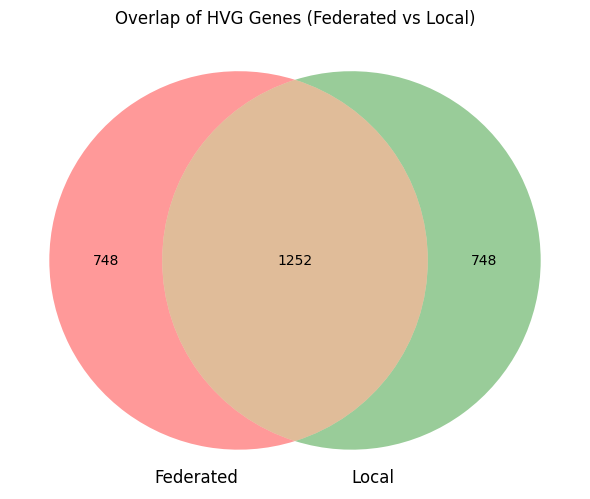

In [3]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Convert to sets of gene names for better comparison
idx_to_gene = get_gene_index_name_dict("./data/pancreas_train.h5ad")

federated_genes = {idx_to_gene[i] for i in federated_indices}
local_genes = {idx_to_gene[i] for i in local_indices}

plt.figure(figsize=(6, 6))
venn2([federated_genes, local_genes], set_labels=('Federated', 'Local'))
plt.title("Overlap of HVG Genes (Federated vs Local)")
plt.tight_layout()
plt.show()
